# 🏓 Entrenamiento de YOLO OBB (Oriented Bounding Boxes)

Este notebook está preparado para ejecutarse en **Lightning.ai** o cualquier entorno Jupyter. Permite descomprimir tu dataset en formato `.zip` y entrenar un modelo YOLO para detectar objetos orientados (rotados).

### 1. Instalación de Dependencias
Instalamos la librería de Ultralytics (YOLO) y otras dependencias necesarias.

In [1]:
# Instalar Ultralytics
%pip install ultralytics roboflow matplotlib opencv-python numpy pyyaml

Note: you may need to restart the kernel to use updated packages.


### 2. Descomprimir el Dataset desde el archivo `.zip`
Asegúrate de haber subido tu archivo `.zip` (descargado de Roboflow) al mismo directorio que este notebook en Lightning.ai.

**Ajusta el nombre del archivo `.zip` en la celda de abajo si es diferente.**

In [2]:
import zipfile
import os
import glob

# Buscar archivos .zip en la carpeta actual y subcarpetas (como dataset/)
zip_files = glob.glob("**/*.zip", recursive=True)

if zip_files:
    # Usar el primer zip encontrado
    ZIP_NAME = zip_files[0] 
    EXTRACT_DIR = "./dataset_obb"

    print(f"📦 Encontrado: {ZIP_NAME}")
    print(f"Descomprimiendo en {EXTRACT_DIR}...")
    with zipfile.ZipFile(ZIP_NAME, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("¡Descompresión completada con éxito!")
    
    # Mostrar el contenido extraído
    print("Contenido:", os.listdir(EXTRACT_DIR))
else:
    print("❌ ERROR: No se encontró ningún archivo .zip. Sube el dataset a la carpeta o a 'dataset/'.")

📦 Encontrado: dataset/Projecto integrador YOLO- TT.v4i.yolov8-obb.zip
Descomprimiendo en ./dataset_obb...


¡Descompresión completada con éxito!
Contenido: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train', 'valid']


### 3. Verificar y corregir rutas en `data.yaml`
Roboflow suele exportar rutas absolutas que pueden no coincidir con el entorno de Lightning.ai. Ejecutamos este bloque para asegurarnos de que las rutas relativas sean correctas.

In [3]:
import yaml
import os

yaml_path = "./dataset_obb/data.yaml"
EXTRACT_DIR = "./dataset_obb"

if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    
    # Ajustamos las rutas de entrenamiento y validación para que sean relativas a la carpeta extraída
    data['path'] = os.path.abspath(EXTRACT_DIR)
    data['train'] = 'train/images'
    data['val'] = 'valid/images'
    if 'test' in data:
        data['test'] = 'test/images'
        
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(data, f, default_flow_style=False)
        
    print("✅ Archivo data.yaml actualizado con éxito:")
    with open(yaml_path, 'r') as f:
        print(f.read())
else:
    print("❌ ERROR: No se encontró el archivo data.yaml en la carpeta especificada.")

✅ Archivo data.yaml actualizado con éxito:
names:
  0: TT Net
  1: TT Racket
  2: TT Table
path: /teamspace/studios/this_studio/TPI-Rede-Neuronales/dataset_obb
test: test/images
train: train/images
val: valid/images



### 4. Configurar y Entrenar el Modelo YOLO OBB
Usamos `yolov8n-obb.pt` (o `yolo11n-obb.pt`) como modelo base. Estos modelos están entrenados para predecir cajas orientadas (con rotación).

In [5]:
import os
import shutil
# 1. Borrar de la carpeta actual si existe
if os.path.exists('yolov8n-obb.pt'):
    os.remove('yolov8n-obb.pt')
    print("Archivo local yolov8n-obb.pt eliminado.")
# 2. Borrar del cache global de Ultralytics (donde a veces se guardan por defecto)
cache_dir = os.path.expanduser('~/.config/Ultralytics/weights')
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir, ignore_errors=True)
    print("Caché global de pesos de Ultralytics limpio.")

Archivo local yolov8n-obb.pt eliminado.


In [7]:
from ultralytics import YOLO

# 1. Cargar el modelo OBB preentrenado
model = YOLO('yolo26n-obb.pt') 

# 2. Entrenar el modelo
results = model.train(
    data      = './dataset_obb/data.yaml', # Ruta al data.yaml que corregimos
    epochs    = 300,                        # 300 épocas solicitadas
    patience  = 50,                         # Early stopping con 50 épocas de paciencia
    imgsz     = 640,                        # Tamaño de imagen
    batch     = 16,                         # Tamaño de lote
    optimizer = 'AdamW',                    # Recomendado para datasets pequeños
    lr0       = 0.001,
    
    # Aumentación de datos
    mosaic    = 1.0,
    mixup     = 0.1,
    degrees   = 15.0,
    translate = 0.1,
    scale     = 0.5,
    fliplr    = 0.5,
    
    # Configuración de guardado
    project   = './runs',
    name      = 'tenis_mesa_obb_run',
    exist_ok  = True,
    save      = True,                       # Asegura que se guarde el mejor modelo (best.pt)
    plots     = True
)

Ultralytics 8.4.60 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset_obb/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tenis_mesa_obb_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True,

### 5. Validar el Modelo
Una vez completado el entrenamiento, podemos validar las métricas obtenidas con el mejor modelo guardado.

In [11]:
import glob
from ultralytics import YOLO

# Buscar dinámicamente el archivo best.pt para evitar errores de rutas de Ultralytics
best_weights = glob.glob('**/weights/best.pt', recursive=True)

if best_weights:
    best_path = best_weights[0]
    print(f"🎯 Cargando mejor modelo desde: {best_path}")
    best_model = YOLO(best_path)
    # Validar
    metrics = best_model.val()
    print("✅ Métricas de validación calculadas con éxito.")
else:
    print("❌ ERROR: No se encontró el archivo best.pt. Asegúrate de haber completado el entrenamiento.")

🎯 Cargando mejor modelo desde: runs/obb/runs/tenis_mesa_obb_run/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26n-obb summary (fused): 132 layers, 2,446,992 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 1200.5±201.0 MB/s, size: 59.0 KB)
val: Scanning /teamspace/studios/this_studio/TPI-Rede-Neuronales/dataset_obb/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 4.2Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.9it/s 0.3s
                   all         10         53      0.812      0.524      0.593      0.383
                TT Net          9         16      0.713      0.562      0.693      0.454
             TT Racket         10         19      0.868      0.347      0.367      0.232
              TT Table         10         18      0.856      0.662      0.719      0.461
Speed: 0.9ms preprocess, 12.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /teamspace/studios/this_studio/TPI-Rede-Neuronales/runs/obb/val
✅ Métricas de validación calculadas con éxito.


### 6. Visualizar Métricas y Gráficos del Entrenamiento
YOLO genera automáticamente gráficos con el progreso de las pérdidas (losses) y las precisiones (mAP50, mAP50-95) a lo largo de las épocas, así como la matriz de confusión.

📊 Cargando resultados de la carpeta: runs/obb/runs/tenis_mesa_obb_run/
--- Curvas de Pérdidas y Métricas (mAP50 / mAP50-95) ---


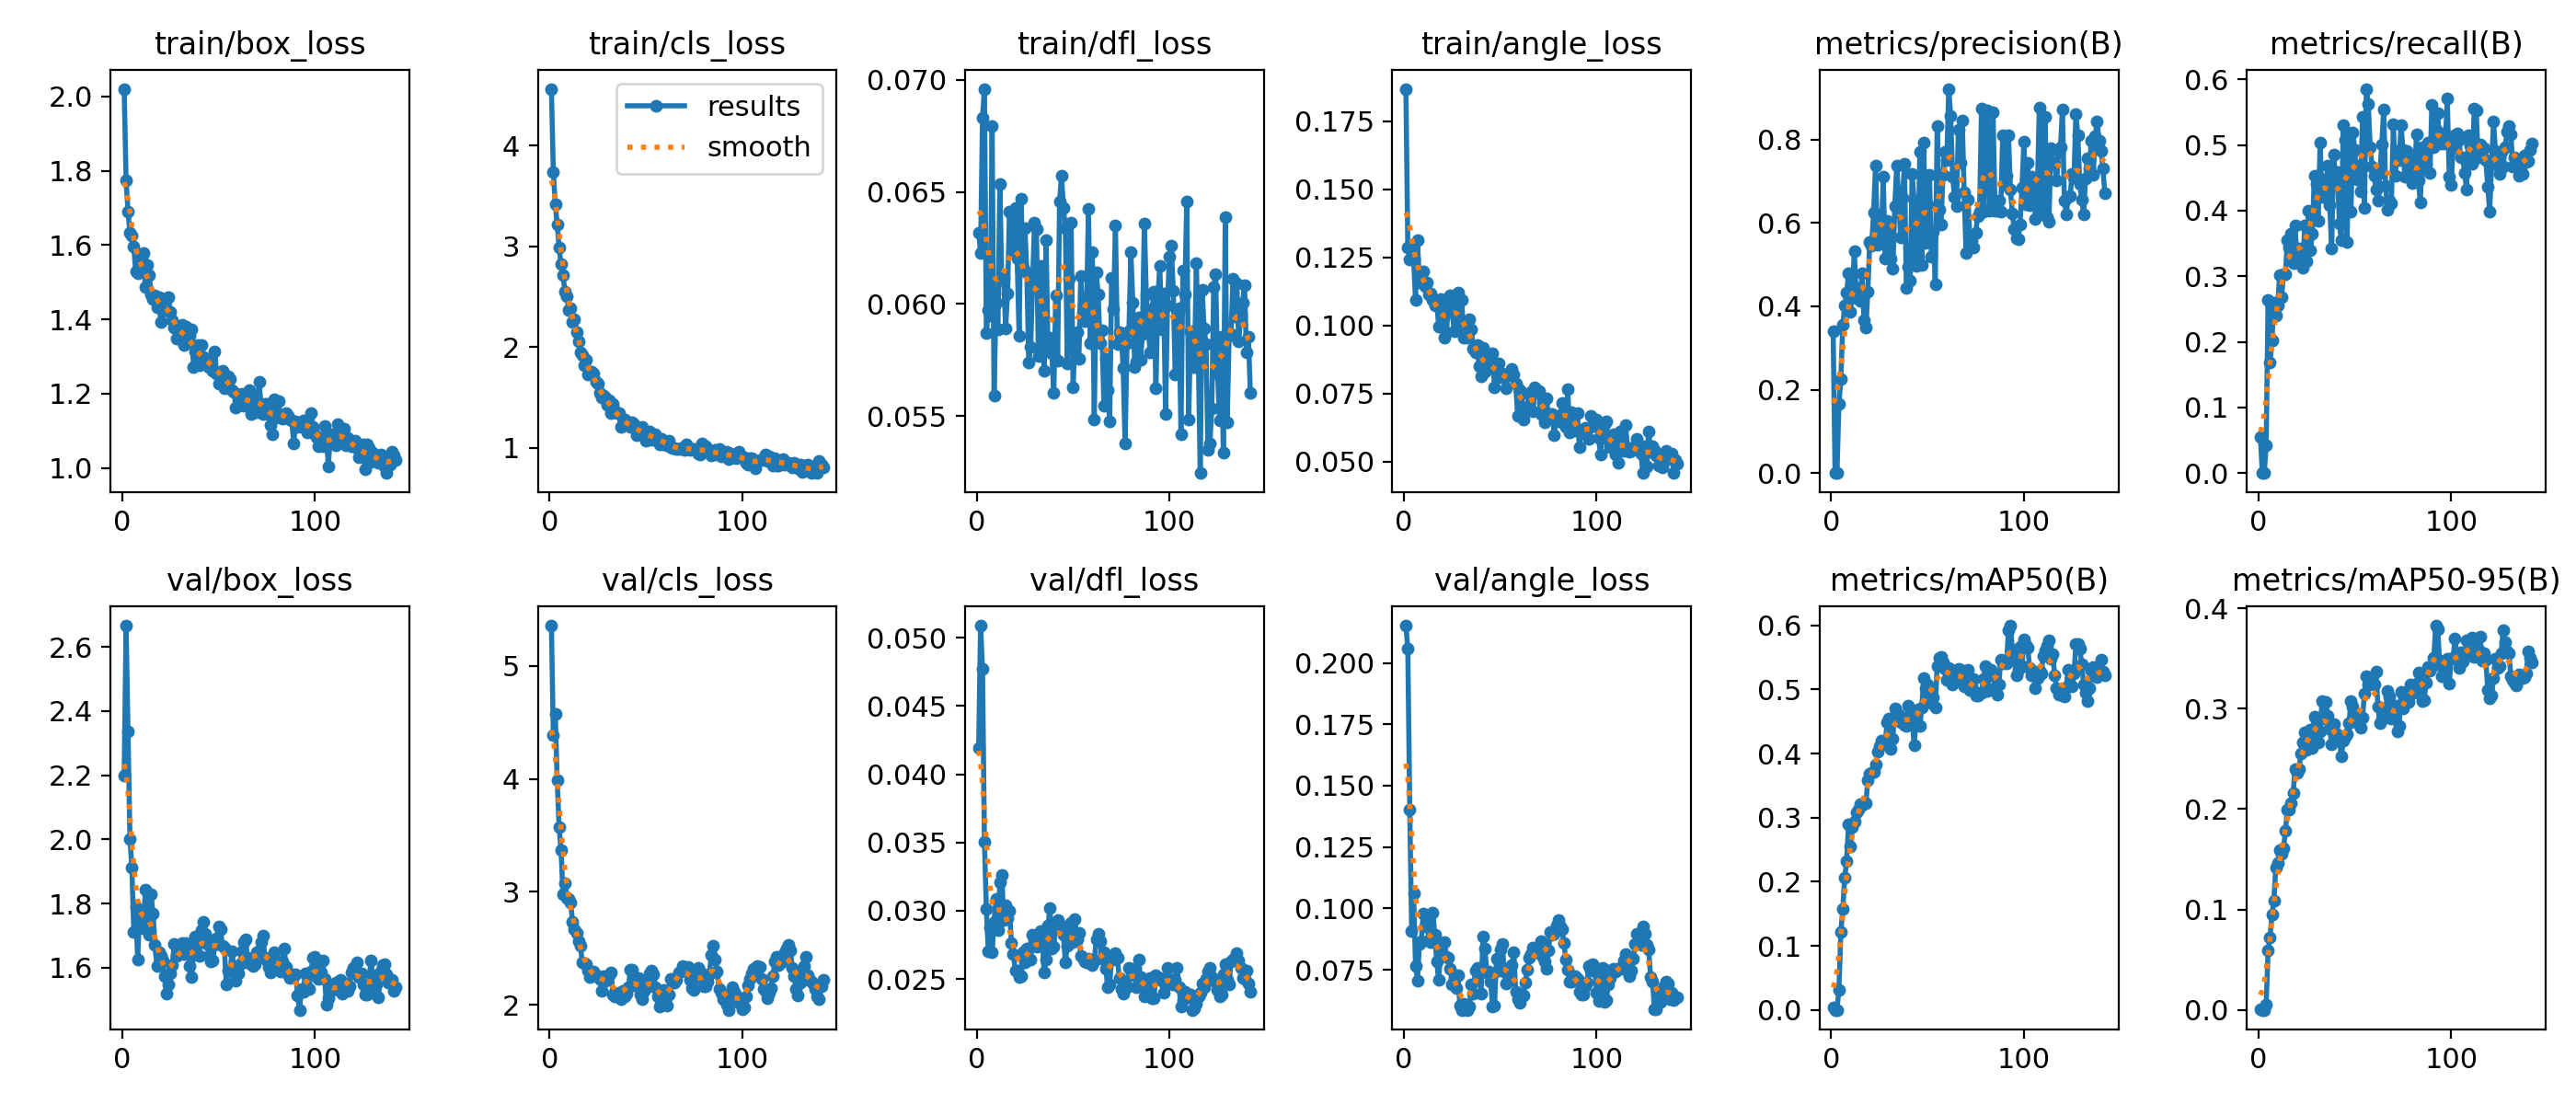


--- Matriz de Confusión ---


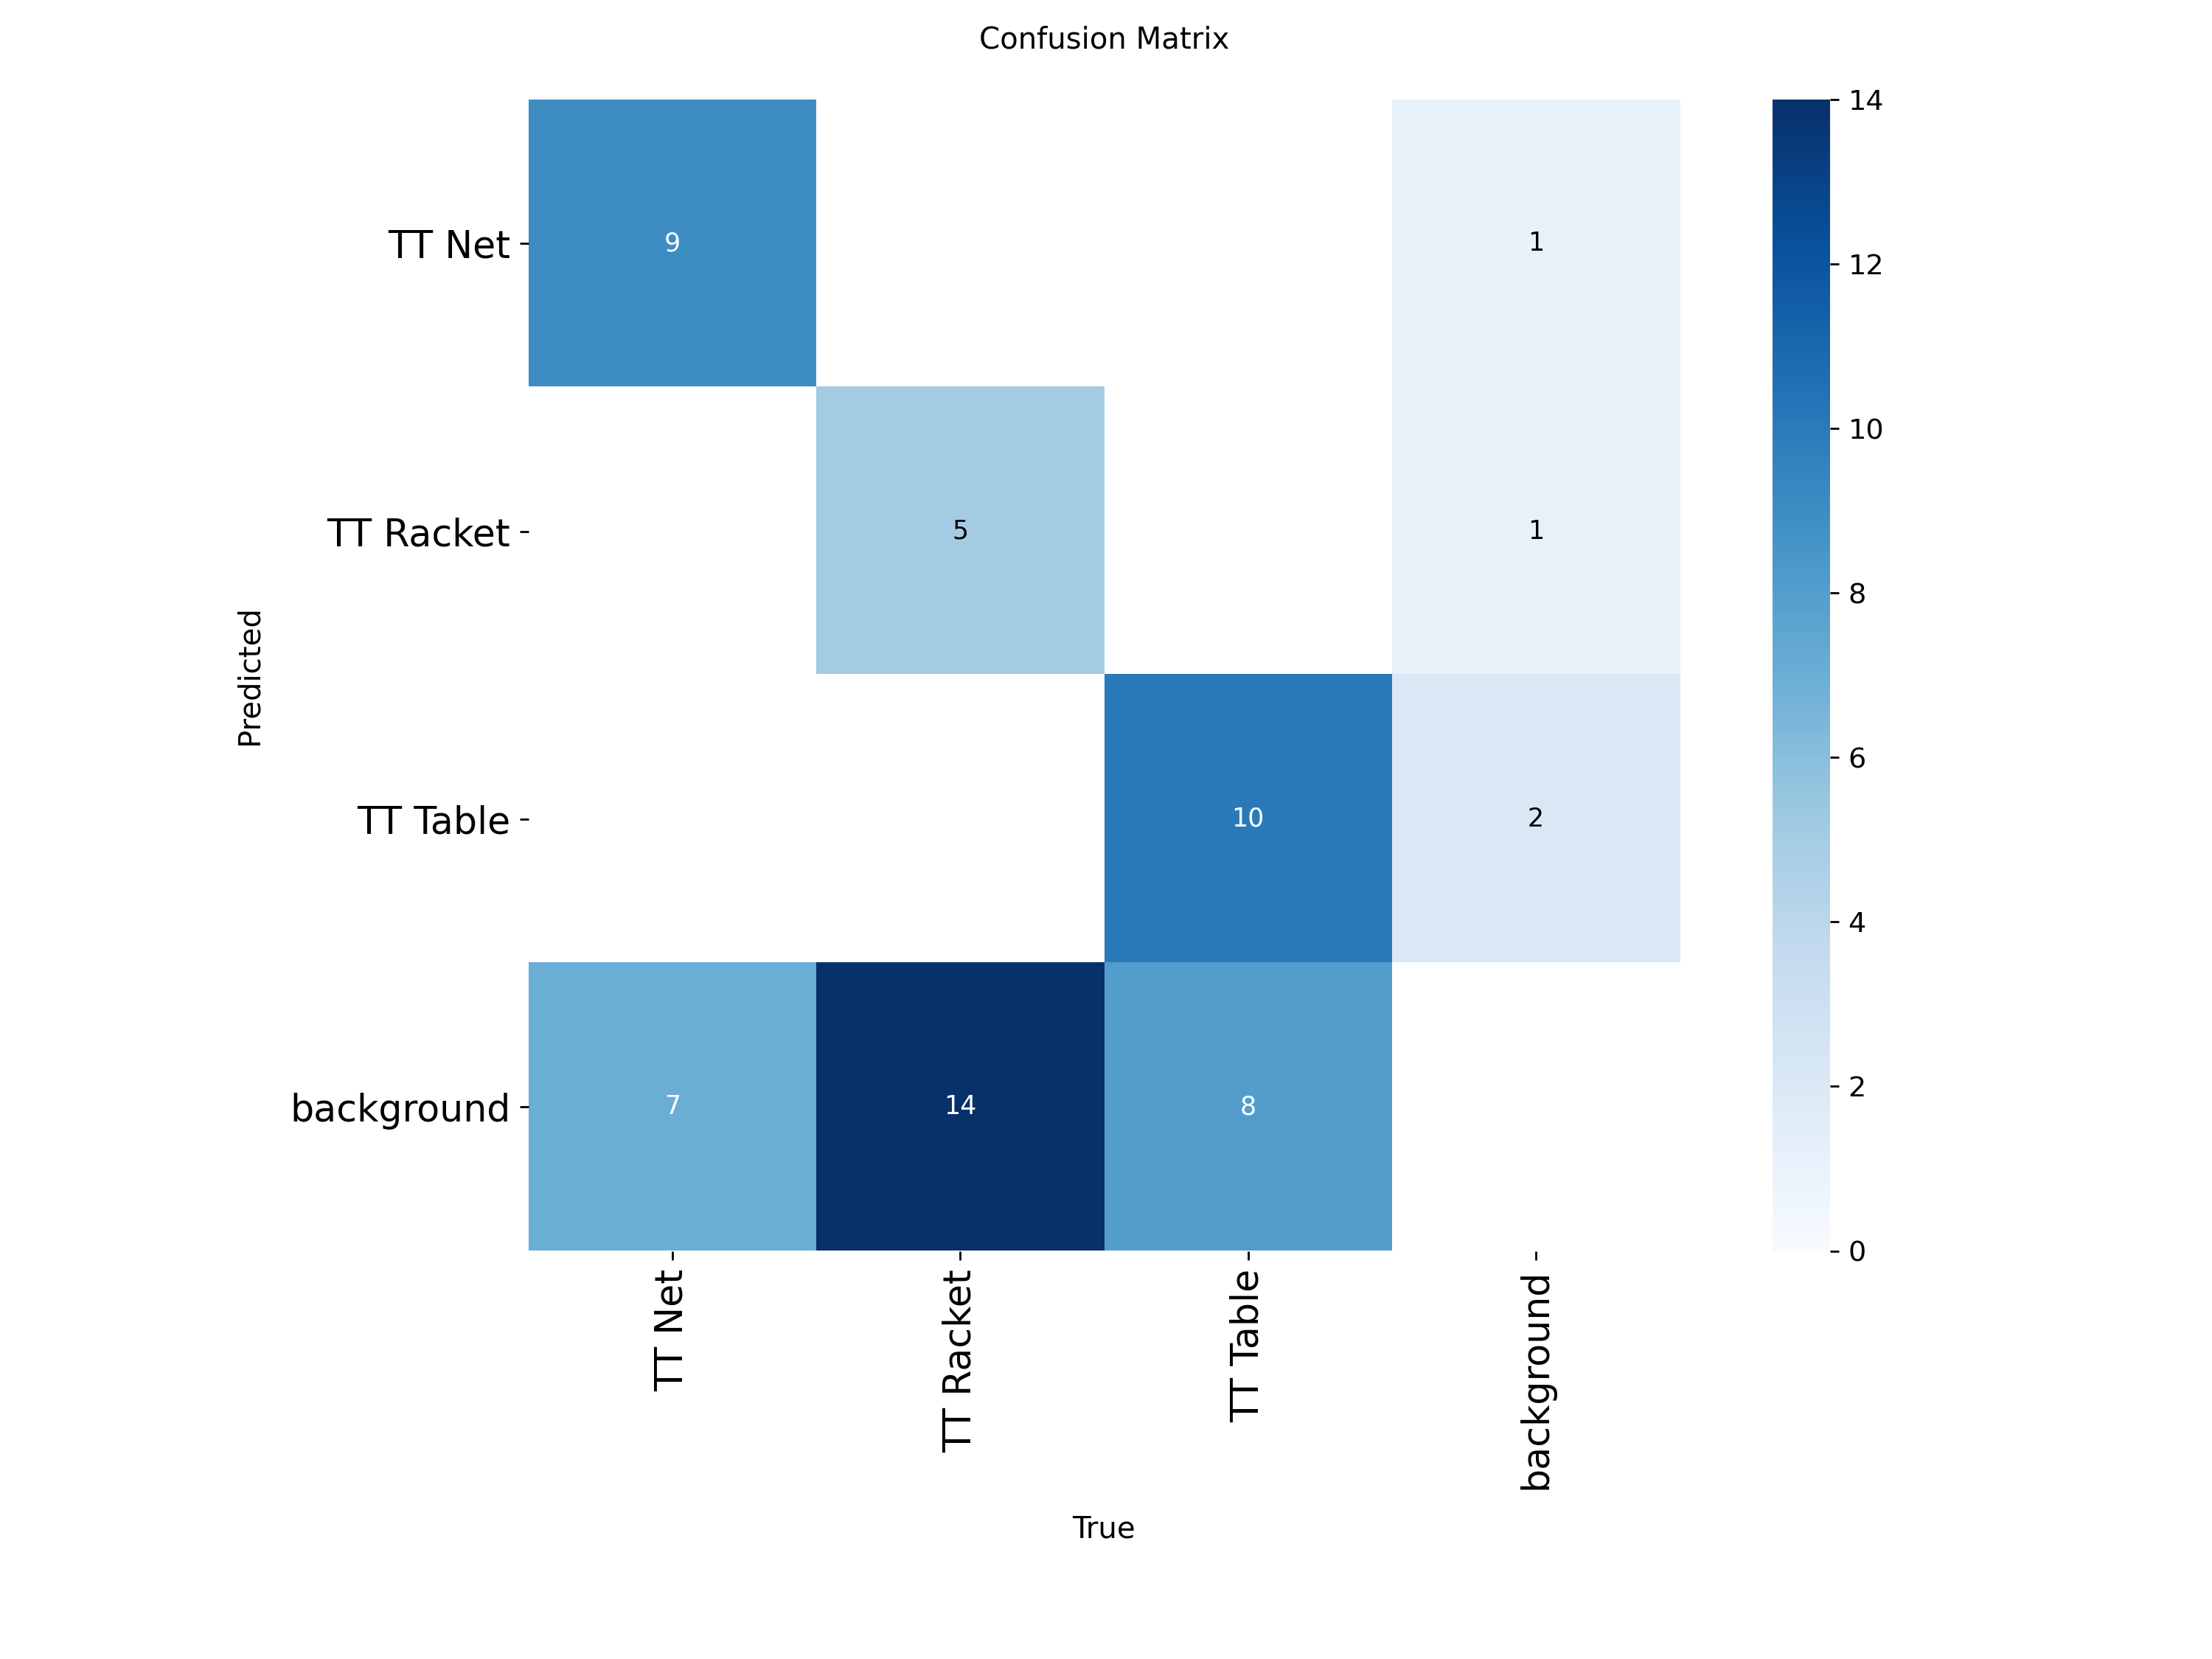

In [12]:
from IPython.display import Image, display
import os
import glob

# Encontrar dinámicamente la carpeta del entrenamiento
results_dirs = glob.glob('**/tenis_mesa_obb_run/', recursive=True)

if results_dirs:
    results_dir = results_dirs[0]
    print(f"📊 Cargando resultados de la carpeta: {results_dir}")

    # 1. Mostrar gráfico de pérdidas y métricas del entrenamiento
    results_png = os.path.join(results_dir, 'results.png')
    if os.path.exists(results_png):
        print("--- Curvas de Pérdidas y Métricas (mAP50 / mAP50-95) ---")
        display(Image(filename=results_png, width=800))
    else:
        print("No se encontró results.png en el directorio de resultados.")

    # 2. Mostrar la Matriz de Confusión
    confusion_matrix_png = os.path.join(results_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_matrix_png):
        print("\n--- Matriz de Confusión ---")
        display(Image(filename=confusion_matrix_png, width=600))
    else:
        print("No se encontró la matriz de confusión.")
else:
    print("❌ ERROR: No se encontró la carpeta del entrenamiento tenis_mesa_obb_run.")